In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("/Users/SANIYA/Machine Learning Project/data/inventory.db")

In [3]:
tb = pd.read_sql_query("select name from sqlite_master where type = 'table'",conn)
for table in tb['name']:
    print('Table name',table)
    df = pd.read_sql (f"select * from {table} limit 5",conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [4]:
purchase_agg_df = pd.read_sql_query("""
select
p.PONumber,
count(distinct p.brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
""",conn)
purchase_agg_df.shape

(5543, 5)

In [5]:
pd.read_sql_query("""
select
vi.quantity as invoice_quantity,
vi.dollars as invoice_dollars,
vi.freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.PODate)) as days_to_pay
from vendor_invoice vi
""",conn)

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,57.0
1,15,140.55,8.57,16.0,61.0
2,5,106.60,4.61,16.0,54.0
3,10100,137483.78,2935.20,23.0,47.0
4,1935,15527.25,429.20,14.0,50.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,51.0
5539,4617,37300.48,186.50,18.0,57.0
5540,9848,202815.78,932.95,11.0,44.0
5541,24747,149007.56,819.54,14.0,50.0


In [6]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
     SELECT
        p.PONumber,
        COUNT(distinct p.brand) as total_brands,
        SUM(p.Quantity) as total_item_quantity,
        SUM(p.Dollars) as total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
    FROM purchases p
    GROUP by p.PONumber
)

SELECT
    vi.quantity as invoice_quantity,
    vi.dollars as invoice_dollars,
    vi.freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.PODate)) as days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay
    
FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
     ON vi.PONumber = pa.PONumber
     
""",conn)


In [7]:
df.isnull().sum()

invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [8]:
df.dtypes

invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [9]:
def create_invoice_risk_label(row) :

    #Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1

    #Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

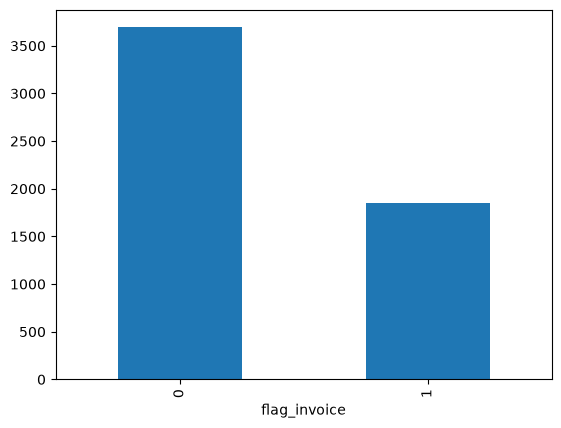

In [10]:
df["flag_invoice"].value_counts().plot(kind = 'bar')

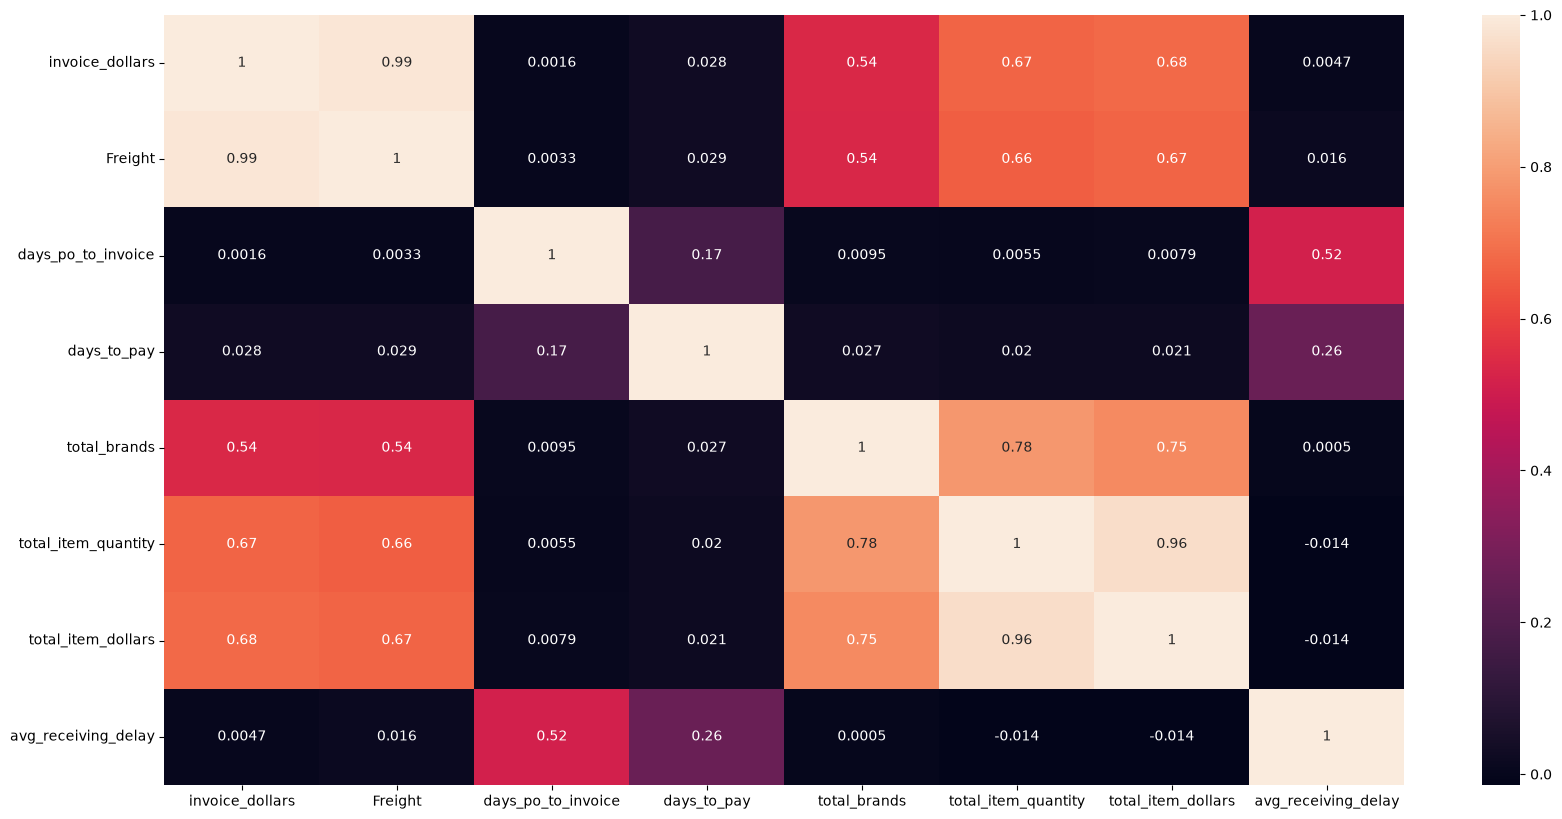

In [11]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:-1].corr(),annot=True)
plt.show()

In [12]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [13]:
significant_features = []
non_significant_features = []
result = []

In [14]:
metrics = ['invoice_quantity','invoice_dollars','Freight',
           'days_po_to_invoice','days_to_pay','total_brands',
           'total_item_quantity','total_item_dollars','avg_receiving_delay']

In [15]:
from scipy.stats import ttest_ind
for metric in metrics:
     flagged_mean = flagged[metric].mean()
     normal_mean = normal[metric].mean()

     t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var = False
    )

     if p_value < 0.05:
        significant_features.append(metric)
        result.append({
            "metric" : metric,
            "flagged_mean" : flagged_mean.round(2),
             "normal_mean" : normal_mean.round(2),
             "p_value" : p_value.round(3)
        })
     else:
        non_significant_features.append(metric)
        print(metric)
        print({
        "metric" : metric,
        "flagged_mean" : flagged_mean.round(2),
        "normal_mean" : normal_mean.round(2),
        "p_value" : p_value.round(3)
        })
    

total_brands
{'metric': 'total_brands', 'flagged_mean': np.float64(42.29), 'normal_mean': np.float64(40.82), 'p_value': np.float64(0.508)}


In [16]:
non_significant_features

['total_brands']

In [17]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'days_to_pay',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [18]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_brands','total_item_quantity','days_po_to_invoice','total_item_dollars']]
y = df['flag_invoice']



In [19]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [39]:
model1 = LogisticRegression()
model1.fit(X_train_scaled,y_train)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [40]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n{model_name} Performance:")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 2))
    print("Classification Report :")
    print(classification_report(y_test, y_pred))

In [41]:
evaluate_model(model1,X_test_scaled,y_test,'Logistic Regression')
evaluate_model(model2,X_test_scaled,y_test,'Decision Tree Regresssion')
evaluate_model(model3,X_test_scaled,y_test,'Random Forest Regresssion')


Logistic Regression Performance:
Accuracy : 0.65
Classification Report :
              precision    recall  f1-score   support

           0       0.65      1.00      0.79       725
           1       0.60      0.01      0.02       384

    accuracy                           0.65      1109
   macro avg       0.63      0.50      0.40      1109
weighted avg       0.64      0.65      0.52      1109


Decision Tree Regresssion Performance:
Accuracy : 0.83
Classification Report :
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       725
           1       0.76      0.77      0.76       384

    accuracy                           0.83      1109
   macro avg       0.82      0.82      0.82      1109
weighted avg       0.84      0.83      0.84      1109


Random Forest Regresssion Performance:
Accuracy : 0.88
Classification Report :
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
   

In [42]:
model3.feature_importances_

array([0.16823231, 0.18566704, 0.16954131, 0.19492416, 0.28163517])

In [43]:
feature_importance = pd.DataFrame({
    "features" : X_train.columns,
    "importance" : model3.feature_importances_
}).sort_values(by = "importance",ascending=False)

In [44]:
feature_importance

,features,importance
4,total_item_dollars,0.281635
3,total_item_quantity,0.194924
1,invoice_dollars,0.185667
2,Freight,0.169541
0,invoice_quantity,0.168232


In [45]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_item_quantity','total_item_dollars']]
y = df['flag_invoice']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)
evaluate_model(model3,X_test_scaled,y_test,'Random Forest Regresssion')


Random Forest Regresssion Performance:
Accuracy : 0.88
Classification Report :
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.94      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



In [49]:
param_grid = {
    "n_estimators":[100,200,300],
    "max_depth" : [None, 4, 5, 6],
    "min_samples_split" : [2,3,5],
    "min_samples_leaf" : [1,2,5],
    "criterion" : ['gini','entropy']
}

In [50]:
from sklearn.metrics import make_scorer,f1_score
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(
    random_state = 42,
    n_jobs = 1
)

param_grid = {
    "n_estimators":[100,200,300],
    "max_depth" : [None, 4, 5, 6],
    "min_samples_split" : [2,3,5],
    "min_samples_leaf" : [1,2,5],
    "criterion" : ['gini','entropy']
}

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    scoring = scorer,
    cv = 5,
    verbose = 2,
    n_jobs = -1
)

grid_search.fit(X_train_scaled,y_train)
evaluate_model(grid_search, X_test_scaled, y_test,'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier Performance:
Accuracy : 0.89
Classification Report :
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.96      0.71      0.82       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.89      1109



In [51]:
from sklearn.metrics import confusion_matrix

In [52]:
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[713, 110],
       [ 12, 274]])

In [53]:
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[706, 109],
       [ 19, 275]])

In [54]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 300}